### Esercizio 3
Si consideri il modello a volatilità stocastica di Heston:
$$
\begin{cases} 
dS_t = \mu S_t dt + \sqrt{\nu_t} S_t dB_t^1, \\ 
d\nu_t = k(\theta - \nu_t) dt + \eta \sqrt{\nu_t} dB_t^2, 
\end{cases} \quad (1)
$$

dove $B^1, B^2$ sono moti Browniani correlati. Si cerchino dei valori “realistici” dei parametri. Assumendo che (1) sia la dinamica in una misura martingala $Q$, col metodo Monte Carlo calcolare il prezzo (in termini di valore atteso in $Q$ del payoff scontato) di una Call Europea con scadenza $T = 0.5$ e $S_0 = 1$ per i valori dello strike $K = 0.5, 0.6, \dots, 1.5$. Visualizzare lo smile di volatilità.

In [137]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulazione di una singola traiettoria
Prima di procedere con il calcolo del prezzo tramite il metodo Monte Carlo, generiamo una singola traiettoria per validare visivamente la dinamica del modello di Heston definita nel sistema (1).
Questa fase permette di osservare l'interazione tra il processo del prezzo $S_t$ e il processo della varianza $\nu_t$. 

In [138]:
S0 = 1.0          # Prezzo iniziale fornito dal testo dell'esercizio
v0 = 0.04         # Varianza iniziale (corrisponde ad una volatilità al 20%), stiamo fornendo una varianza iniziale 
                  # strettamente maggiore di zero
r = 0.03          # Tasso risk-free (siamo sotto la misura martingala Q)
kappa = 5.0       # Velocità di ritorno verso la media, chiamata velocità di mean-reversion determina quanto velocemente
                  # la varianza torna verso il suo valore medio dopo che uno shock ne ha causato un aumento o una diminuzione.
theta = 0.04      # Media di lungo periodo della varianza (varianza di lungo periodo), cioè è il livello a cui la volatilità 
                  # tende a ritornare nel lun
eta = 0.3         # Volatilità della volatilità (Volatilità della varianza): determina l'ampiezza delle fluttuazioni della varianza stessa.
rho = -0.7       # Correlazione tra prezzo e varianza, cioè la correlazione tra i due moti browniani
T = 0.5           # Corrisponde a un orizzonte temporale di 6 mesi.
n_steps = 500     # Suddividiamo in 500 intervalli 
dt = T / n_steps  # Ampiezza di ogni intervallo temporale
t = np.linspace(0, T, n_steps+1) 

#### Verifica della Condizione di Feller
La Condizione di Feller è fondamentale nel modello di Heston per garantire che il processo della varianza $\nu_t$ 
rimanga strettamente positivo ($\nu_t > 0$) e non tocchi mai lo zero, rendendo la simulazione molto più stabile.
La condizione è definita come:
$$2\kappa\theta > \eta^2$$
Sostituendo i valori scelti si ottiene che 
$$2 \cdot (5.0) \cdot (0.04) = 0.40$$
e
$$\eta^2 = (0.3)^2 = 0.09$$

Poiché **$0.40 > 0.09$**, la condizione è ampiamente soddisfatta. Quindi la varianza non può diventare negativa. 

In [139]:
# Inizializzazione
S_path = np.zeros(n_steps+1)
v_path = np.zeros(n_steps+1)
S_path[0] = S0
v_path[0] = v0

#### Gestione della Stabilità Numerica: Strategia di Troncamento
Nella discretizzazione del modello di Heston tramite lo schema di Eulero, può accadere che shock stocastici particolarmente negativi spingano il valore della varianza $\nu_t$ al di sotto dello zero. Questo rappresenta un problema computazionale, poiché la dinamica (1) prevede il calcolo della radice quadrata $\sqrt{\nu_t}$.
Per ovviare a questo problema e garantire la convergenza dell'algoritmo, abbiamo adottato la strategia di troncamento totale. Definiamo la variabile
$$\nu^+ = \max(\nu_t, 0),$$
la strategia prevede che la varianza venga posta a zero ogni volta che assume valori negativi, prima di passare all'iterazione temporale successiva.

In [140]:
for i in range(n_steps):
    # Generiamo shock correlati
    z1 = np.random.normal()
    z2 = rho * z1 + np.sqrt(1 - rho**2) * np.random.normal()
    
    v_plus = max(v_path[i], 0)
    
    dv = kappa * (theta - v_plus) * dt + eta * np.sqrt(v_plus * dt) * z2  
    v_path[i+1] = v_path[i] + dv
    
    dS = r * S_path[i] * dt + np.sqrt(v_plus * dt) * S_path[i] * z1      
    S_path[i+1] = S_path[i] + dS

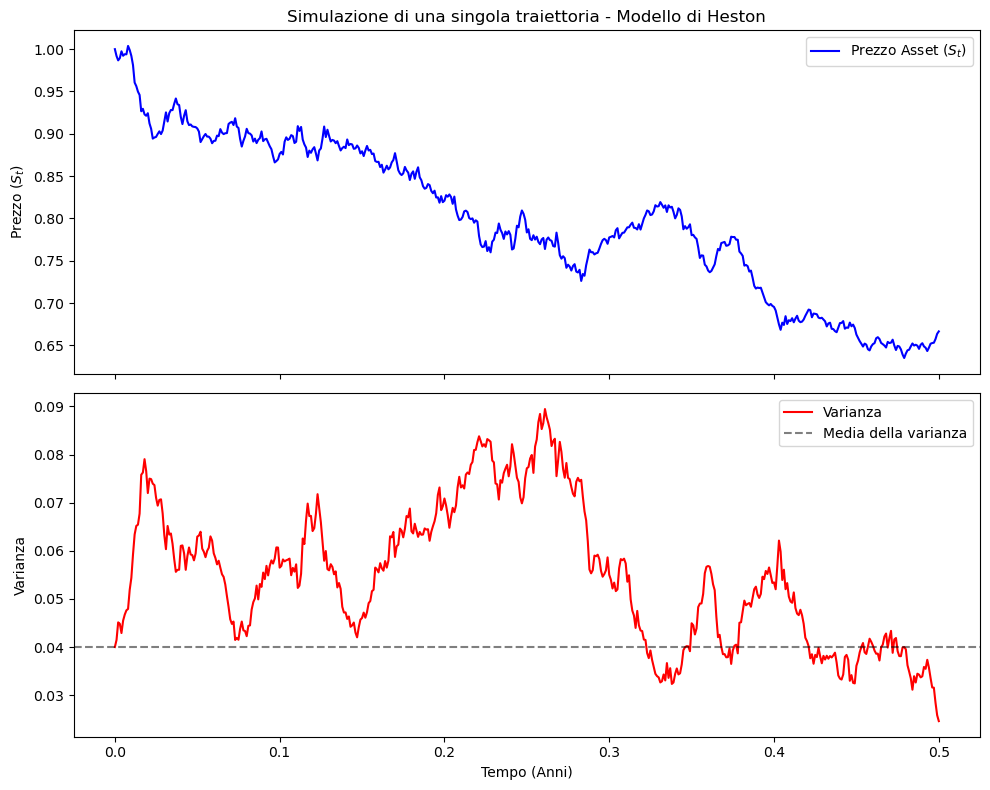

In [141]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(t, S_path, color='blue', label='Prezzo Asset ($S_t$)')
ax1.set_ylabel('Prezzo ($S_t$)')
ax2.set_xlabel('Tempo (Anni)')
ax1.legend()
ax1.set_title('Simulazione di una singola traiettoria - Modello di Heston')

ax2.plot(t, v_path, color='red', label='Varianza')
ax2.axhline(theta, color='black', linestyle='--', alpha=0.5, label='Media della varianza')
ax2.set_ylabel('Varianza')
ax2.set_xlabel('Tempo (Anni)')
ax2.legend()

plt.tight_layout()
plt.show()

### Analisi della traiettoria
Come si osserva nel grafico, la varianza presenta una mean reversion. La linea rossa tende a tornare verso il livello $\theta = 0.04$, che rappresenta la media di lungo periodo. In presenza di uno shock, $\kappa$ è la forza che trascina il processo nuovamente verso la media.
Attraverso una serie di test effettuati variando la velocità di ritorno alla media, abbiamo osservato i seguenti comportamenti:

Se $\kappa$ aumenta (es. $\kappa = 10$), la varianza $\nu_t$ resta attornoal valore $\theta = 0.04$ e l'effetto della volatilità stocastica svanisce quasi del tutto. Di conseguenza, il modello diventa molto simile a un semplice Black-Scholes.

Se $\kappa$ diminuisce (es. $\kappa = 2$): il debole richiamo verso la media consente alla varianza di allontanarsi significativamente dal valore centrale, innescando così persistenti fenomeni di volatility clustering. Inoltre, l'incertezza aumenta, rendendo le opzioni molto più costose.

Per la nostra simulazione finale abbiamo scelto **$\kappa = 5$**. Questo valore rappresenta un equilibrio ideale, permettendo alla varianza di oscillare in modo realistico e assicurando che il sistema torni in equilibrio senza divergere.

# 2. Estensione: simulazione Monte Carlo con 100.000  traiettorie
Dopo aver validato il comportamento del modello su una singola traiettoria, estendiamo l'analisi al caso di 100.000 traiettorie.
In questa fase, ci concentreremo su un singolo valore di strike fisso, K=0.5, per illustrare il processo di calcolo del prezzo del derivato tramite il metodo Monte Carlo.

In [142]:
S0 = 1.0          # Prezzo iniziale 
v0 = 0.04         # Varianza iniziale (volatilità 20%)
r = 0.03          # Tasso risk-free 
kappa = 5.0       # Velocità di ritorno verso la media 
theta = 0.04      # Media di lungo periodo della varianza 
eta = 0.3         # Volatilità della volatilità 
rho = -0.7       # Correlazione tra prezzo e varianza

T = 0.5           
n_steps = 500     # Suddividiamo il periodo in n_steps intervalli 
dt = T / n_steps

In [143]:
n_paths = 100000 # Numero di traiettorie 
K = 0.5          # Strike Price fisso per ora

In [144]:
S_paths = np.zeros((n_steps + 1, n_paths))
v_paths = np.zeros((n_steps + 1, n_paths))
S_paths[0] = S0
v_paths[0] = v0

In [145]:
for t in range(0, n_steps):
    z1 = np.random.normal(size=n_paths)
    z2 = rho * z1 + np.sqrt(1 - rho**2) * np.random.normal(size=n_paths)
    
    v_plus = np.maximum(v_paths[t,:], 0)
    
    v_paths[t+1,:] = v_paths[t,:] +  kappa * (theta - v_plus) * dt + eta * np.sqrt(v_plus) * np.sqrt(dt) * z2
    S_paths[t+1,:] = S_paths[t,:] +  r * S_paths[t,:] * dt + np.sqrt(v_plus) * S_paths[t,:] * np.sqrt(dt) * z1  

In [146]:
# Calcolo del payoff per ogni traiettoria generata 
payoffs_fixed = np.maximum(S_paths[-1,:] - K, 0)

# Pricing 
price_fixed = np.exp(-r * T) * np.mean(payoffs_fixed)

print(f"Risultato per Strike K = {K}:")
print(f"Prezzo della Call Europea: {price_fixed:.5f}")

Risultato per Strike K = 0.5:
Prezzo della Call Europea: 0.50804


In [147]:
std_err = np.std(payoffs_fixed) / np.sqrt(n_paths)
print(f"Errore Standard della stima MC: {std_err:.6f}")

Errore Standard della stima MC: 0.000445


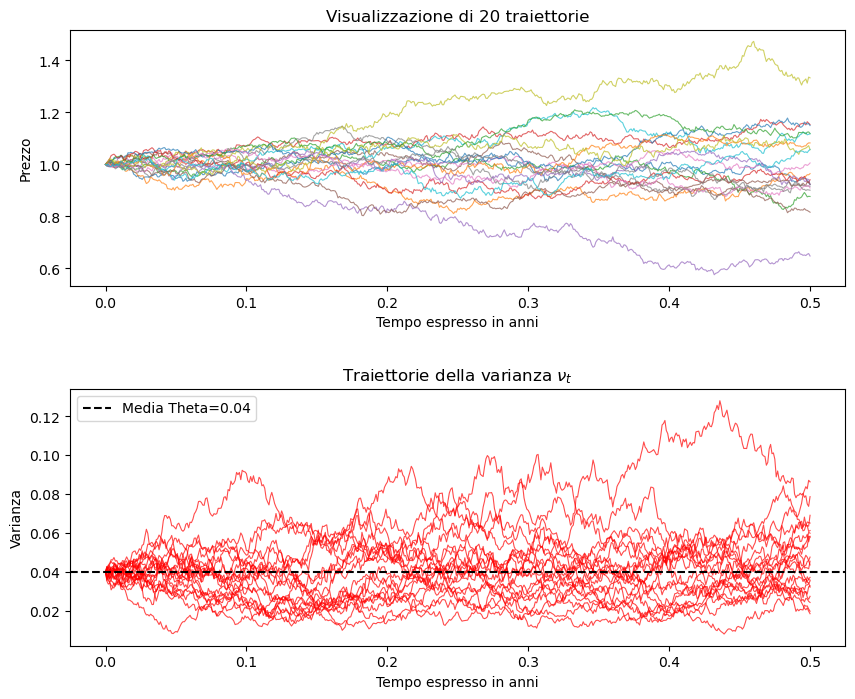

In [148]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plt.subplots_adjust(hspace=0.4)

ax1.plot(np.linspace(0, T + 1e-8, n_steps+1), S_paths[:,0:20], lw=0.8, alpha=0.7)
ax1.set_title("Visualizzazione di 20 traiettorie")
ax1.set_ylabel("Prezzo")
ax1.set_xlabel("Tempo espresso in anni")

ax2.plot(np.linspace(0, T + 1e-8, n_steps+1), v_paths[:,0:20], lw=0.8, alpha=0.7, color='red')
ax2.axhline(theta, color='black', linestyle='--', label=f'Media Theta={theta}')
ax2.set_title("Traiettorie della varianza $\\nu_t$")
ax2.set_ylabel("Varianza")
ax2.set_xlabel("Tempo espresso in anni")
ax2.legend()

plt.show()

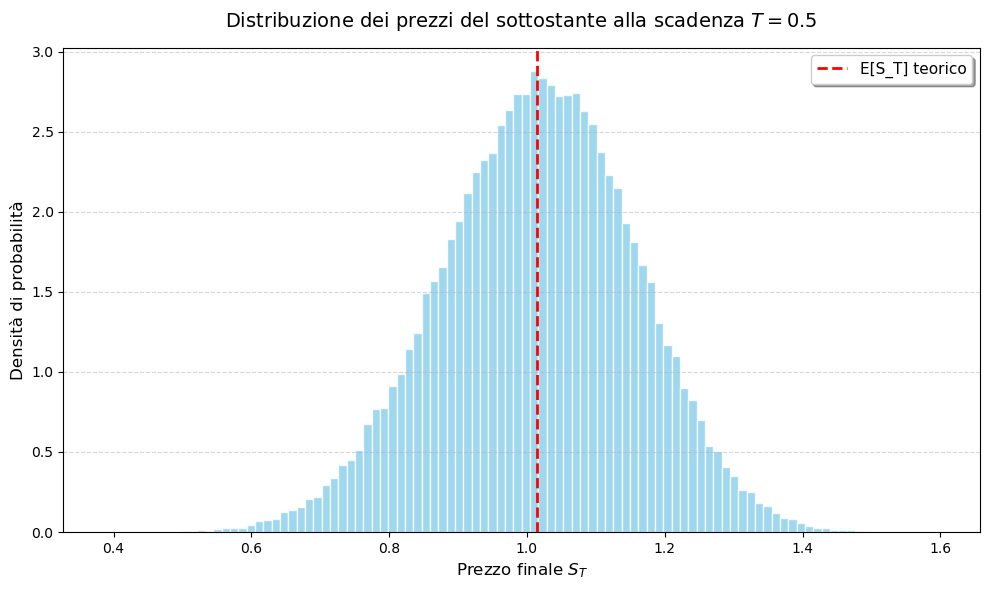

In [149]:
S_T = S_paths[-1, :]
fig, ax3 = plt.subplots(figsize=(10, 6))
ax3.hist(S_T, bins=100, density=True, color='skyblue', edgecolor='white', alpha=0.8)
ax3.axvline(S0 * np.exp(r*T), color='red', linestyle='--', linewidth=2, 
            label='E[S_T] teorico')
ax3.set_title("Distribuzione dei prezzi del sottostante alla scadenza $T=0.5$", fontsize=14, pad=15)
ax3.set_xlabel("Prezzo finale $S_T$", fontsize=12)
ax3.set_ylabel("Densità di probabilità", fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.5)
ax3.legend(frameon=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

### Analisi della Distribuzione dei Prezzi $S_T$ alla Scadenza
L'istogramma sopra riportato rappresenta la densità di probabilità empirica dei prezzi finali generati dalle n_paths = 100.000 simulazioni Monte Carlo. 
Dall'analisi del grafico si può notare una skewness negativa (asimmetria): si nota una chiara pendenza negativa, caratterizzata da una coda sinistra più lunga. Questa asimmetria è la conseguenza diretta della correlazione negativa tra gli shock del prezzo e quelli della varianza. Quando il prezzo diminuisce, la volatilità tende ad aumentare, amplificando la probabilità di ottenere rendimenti negativi estremi.

# 3. Pricing al variare dello Strike Price
Dopo aver validato l'accuratezza dell'algoritmo su un singolo valore di strike, estendiamo l'analisi all'intero set di strike price forniti dal testo dell'esercizio ($K \in [0.5, 1.5]$). 
L'obiettivo di questa sezione è vedere come il valore della call europea vari in funzione di $K$. Per massimizzare l'efficienza del calcolo, utilizzeremo le traiettorie già simulate, applicando la funzione di payoff ai valori finali $S_T$ per ogni livello di strike richiesto.

Strike (K) | Prezzo Call     | Stato          
---------------------------------------------
0.5        | 0.50804         | ITM            
0.6        | 0.40960         | ITM            
0.7        | 0.31174         | ITM            
0.8        | 0.21674         | ITM            
0.9        | 0.13075         | ITM            
1.0        | 0.06367         | ITM            
1.1        | 0.02288         | OTM            
1.2        | 0.00557         | OTM            
1.3        | 0.00085         | OTM            
1.4        | 0.00007         | OTM            
1.5        | 0.00000         | OTM            


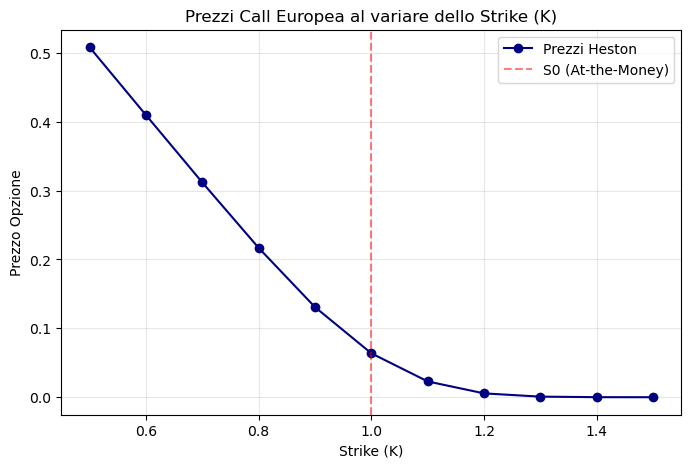

In [150]:
strikes = np.arange(0.5, 1.6, 0.1) 
# array degli strike: 0.5, 0.6, ..., 1.5 fornito dal testo
heston_prices = []

print(f"{'Strike (K)':<10} | {'Prezzo Call':<15} | {'Stato':<15}")
print("-" * 45)

for K in strikes:
    payoffs = np.maximum(S_paths[-1,:] - K, 0)
    
    price = np.exp(-r * T) * np.mean(payoffs)
    heston_prices.append(price)
    
    # mettiamo un etichetta per capire dove ci troviamo rispetto a S0=1.0
    status = "ITM" if K < 1.0 else ("ATM" if K == 1.0 else "OTM")
    print(f"{K:<10.11} | {price:<15.5f} | {status:<15}")

plt.figure(figsize=(8, 5))
plt.plot(strikes, heston_prices, 'o-', color='navy', label='Prezzi Heston')
plt.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='S0 (At-the-Money)')
plt.title("Prezzi Call Europea al variare dello Strike (K)")
plt.xlabel("Strike (K)")
plt.ylabel("Prezzo Opzione")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analisi della Curva dei Prezzi delle Opzioni Call

L'analisi del grafico evidenzia innanzitutto che il prezzo della Call è una funzione decrescente dello strike price, 
raggiungendo il suo valore massimo per $K = 0.5$ quando l'opzione si trova in una condizione di Deep In-the-Money. 
L'andamento non segue una linea retta ma descrive una curva con una convessità molto pronunciata, 
che risulta particolarmente evidente nel punto At-the-Money ($K = 1.0$) dove lo strike coincide con il valore attuale del sottostante. 
In questa zona specifica, la componente del valore temporale è molto significativa proprio perché l'incertezza sul payoff finale è massima.
Infine, per strike superiori a 1.2 l'opzione entra in territorio Out-of-the-Money e il prezzo subisce un naturale decadimento. 
Tuttavia, grazie alla volatilità stocastica e a ($\rho = -0.7$), il modello di Heston genera una distribuzione caratterizzata dalle cosiddette code grasse. Questo permette alle opzioni con strike molto lontani di mantenere comunque un piccolo valore positivo, riflettendo correttamente il costo della protezione contro eventi di mercato rari ma violenti che altri modelli non riuscirebbero a catturare.

In [151]:
from scipy.stats import norm
from scipy.optimize import brentq

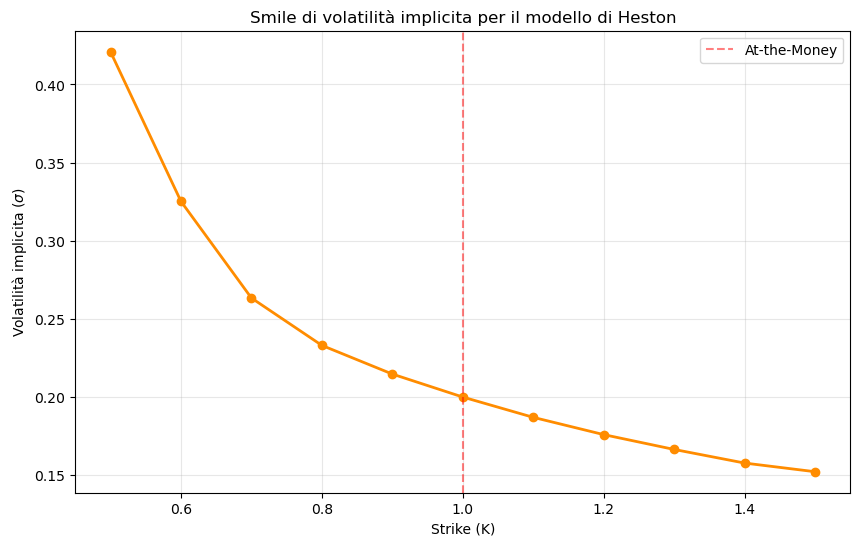

In [152]:
# Il primo passo è quello di definire la funzione bs_call_price
def bs_call_price(sigma, S, K, T, r):
    if sigma <= 0: 
        return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Poi definiamo la funzione di volatilità implicita
def implied_vol(target_price, S, K, T, r):
    # Cerchiamo la sigma tra lo 0.01% e il 500%
    try:
        return brentq(lambda x: bs_call_price(x, S, K, T, r) - target_price, 1e-6, 5.0)
    except:
        print(f"Avviso: IV non calcolabile per Strike K={K:.2f} (Prezzo simulato: {target_price:.5f})")
        return np.nan  # Il prezzo è fuori dai limiti: avvisiamo l'utente e restituiamo NaN
        
# calcoliamo lo smile
ivs = []
for i in range(len(strikes)):
    vol = implied_vol(heston_prices[i], S0, strikes[i], T, r)
    ivs.append(vol)

plt.figure(figsize=(10, 6))
plt.plot(strikes, ivs, 'o-', color='darkorange', linewidth=2)
plt.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='At-the-Money')
plt.title("Smile di volatilità implicita per il modello di Heston")
plt.xlabel("Strike (K)")
plt.ylabel("Volatilità implicita ($\sigma$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [153]:
import pandas as pd
import numpy as np

df_risultati = pd.DataFrame({
    'Strike (K)': strikes,
    'Prezzo Heston': heston_prices,
    'Volatilità Implicita (IV)': ivs
})

df_risultati['Volatilità Implicita (IV)'] = df_risultati['Volatilità Implicita (IV)'].map(lambda x: f"{x*100:.2f}%" if not np.isnan(x) else "N/A")
df_risultati['Prezzo Heston'] = df_risultati['Prezzo Heston'].map('{:.5f}'.format)
df_risultati['Strike (K)'] = df_risultati['Strike (K)'].map('{:.2f}'.format)

print("Tabella riassuntiva: prezzi e volatilità implicita")
display(df_risultati)

Tabella riassuntiva: prezzi e volatilità implicita


,Strike (K),Prezzo Heston,Volatilità Implicita (IV)
0,0.50,0.50804,42.10%
1,0.60,0.40960,32.52%
2,0.70,0.31174,26.33%
3,0.80,0.21674,23.29%
4,0.90,0.13075,21.46%
5,1.00,0.06367,19.99%
6,1.10,0.02288,18.69%
7,1.20,0.00557,17.58%
8,1.30,0.00085,16.63%
9,1.40,0.00007,15.76%


### Analisi dello Smile di Volatilità
Questo risultato conferma che il modello di Heston, a differenza del modello di Black-Scholes, è in grado di catturare l'asimmetria dei rendimenti osservata nei mercati reali.
In particolare, la pendenza decrescente della curva è coerente con il parametro di correlazione $\rho = -0.7$ impostato nella simulazione. Inoltre, tale valore riflette la tendenza della volatilità ad aumentare durante le fasi di ribasso del mercato. Questo fenomeno rende le opzioni con strike bassi relativamente più costose, poiché il modello assegna una probabilità maggiore agli eventi estremi negativi (code più spesse a sinistra) rispetto a una distribuzione normale.